In [1]:
!pip install linearmodels wrds scikit-learn -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


ADVANCED ANALYSIS: Crash Risk & Earnings Management
Including: Jones Model, PSM, Fama-MacBeth, Interaction Effects

[Section 1] Connecting to WRDS...

[1.1] Downloading Compustat (Extended for Jones Model)...
  All critical fields present.
  Loaded: comp=(13152, 37), crsp=(13934514, 5), ccm=(33324, 6)

[1.3] Downloading CCM Linking Table...
  Data ready: comp=(13152, 37), crsp=(13934514, 6), weekly=(2892340, 5)

  [Optimized] Vectorized CCM matching...
  [Fix] ccm already has permno
  CCM Match: 13152 firm-years
  With CRSP linkage: 13152

[Section 3] Computing Crash Risk Metrics...

[Section 3] Computing Crash Risk Metrics...
  Crash metrics computed: 57484 valid observations

[Step 4] Calculating Accruals...
✓ Accruals calculation complete: 9907 records

[Section 5] Merging Datasets & Diagnostics...
  crash_metrics: 57484 rows, 7506 companies
  comp: 9942 rows, 2923 companies
  Common permno: 2193
  crash_metrics years: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013),

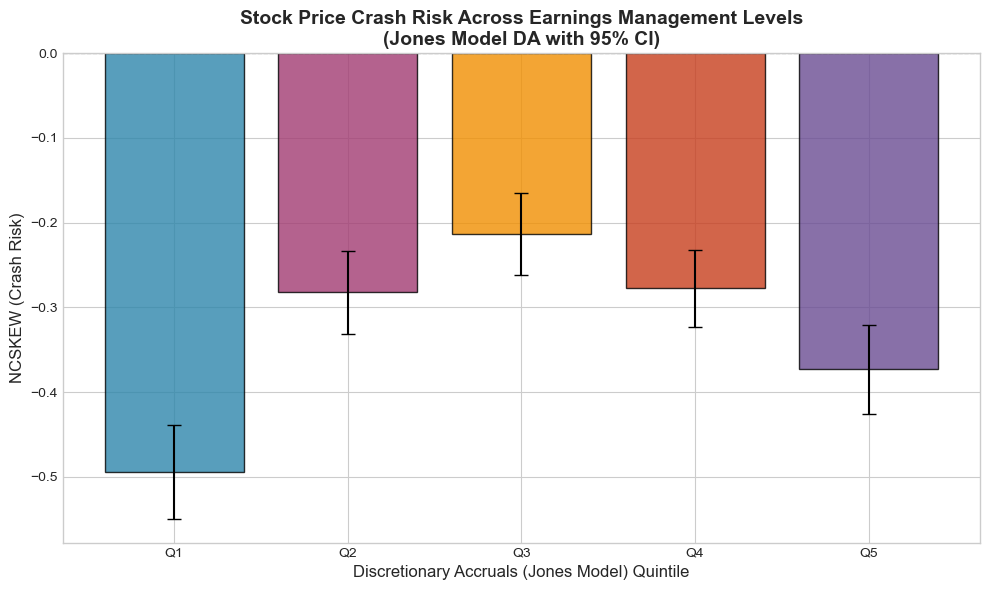

  Figure 1 saved


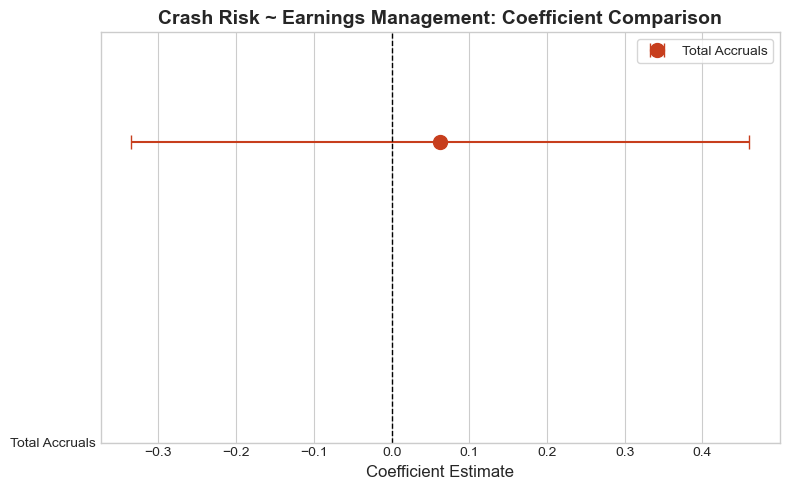

  Figure 2 saved


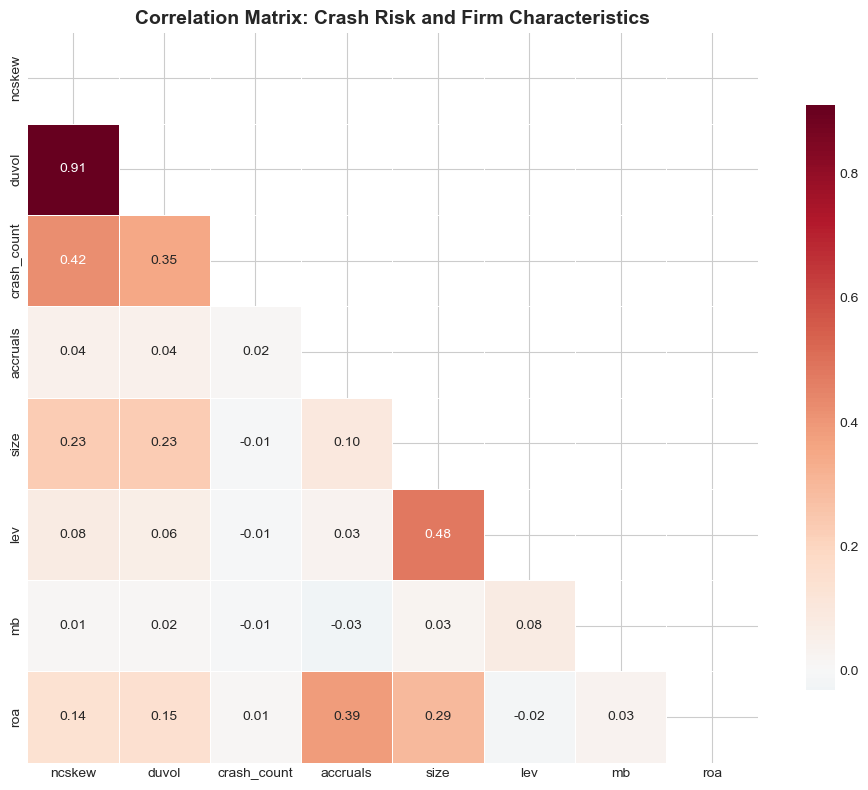

  Figure 3 saved

[Section 10] Exporting Results...
  Regression tables saved to: tables/regression_results.csv
  Final sample saved to: data/final_analysis_sample.csv

ADVANCED ANALYSIS COMPLETE
Outputs:
  - Figures: figures/fig1_*.png, fig2_*.png, fig3_*.png
  - Tables: tables/regression_results.csv
  - Data: data/final_analysis_sample.csv


In [2]:
# ============================================================
# ACC102 Track 2: Advanced Stock Price Crash Risk Analysis
# Methodology: Jones Model Accruals + Panel IV + PSM Robustness
# Data: WRDS (Compustat + CRSP + CCM)
# Access Date: April 2026
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import cdist
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS
from linearmodels.iv import IVGMM  # Instrumental variable regression
# import wrds  
import os
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
warnings.filterwarnings('ignore')

# Academic figure style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.float_format', lambda x: '%.4f' % x)
np.random.seed(2026)

# Create output directories
for folder in ['data', 'figures', 'tables']:
    os.makedirs(folder, exist_ok=True)

print("=" * 70)
print("ADVANCED ANALYSIS: Crash Risk & Earnings Management")
print("Including: Jones Model, PSM, Fama-MacBeth, Interaction Effects")
print("=" * 70)


# -----------------------------------------------------------
# Section 1: Advanced Data Retrieval with Validation
# -----------------------------------------------------------

print("\n[Section 1] Connecting to WRDS...")
#conn = wrds.Connection()

START_YEAR = 2018
END_YEAR = 2023

# --- 1.1 Compustat with Extended Variables for Jones Model ---
print(f"\n[1.1] Downloading Compustat (Extended for Jones Model)...")

# Jones Model requires: sale, rect, ppegt (or ppent)
# We query both standard and Jones-specific fields
USE_WRDS = False

if USE_WRDS:
    pass
else:
    comp = pd.read_csv('data/compustat_raw.csv')
    crsp = pd.read_csv('data/crsp_daily.csv')
    ccm = pd.read_csv('data/ccm_link.csv')
    
    if 'lpermno' in ccm.columns and 'permno' not in ccm.columns:
        ccm = ccm.rename(columns={'lpermno': 'permno'})
        print("  [Fix] ccm: lpermno -> permno")
    
    critical_fields = ['at', 'ni', 'act', 'che', 'lct', 'sale', 'rect', 'ppegt']
    missing = [f for f in critical_fields if f not in comp.columns]
    if missing:
        print(f"  WARNING: Missing {missing}")
    else:
        print(f"  All critical fields present.")
    
    print(f"  Loaded: comp={comp.shape}, crsp={crsp.shape}, ccm={ccm.shape}")

crsp_query = f"""
SELECT 
a.permno, a.date, a.ret, a.vol, a.shrout
FROM crsp.dsf AS a
INNER JOIN crsp.msenames AS b 
    ON a.permno = b.permno 
    AND a.date BETWEEN b.namedt AND b.nameendt
WHERE b.shrcd IN (10, 11)
  AND b.exchcd IN (1, 2, 3)
  AND a.date BETWEEN '{START_YEAR}-01-01' AND '{END_YEAR+1}-06-30'
  AND a.ret IS NOT NULL
"""
#crsp = conn.raw_sql(crsp_query)
#print(f"  Downloaded: {crsp.shape[0]} rows, {crsp['permno'].nunique()} stocks")
#crsp.to_csv('data/crsp_daily.csv', index=False)

# --- 1.3 CCM Linking Table ---
print(f"\n[1.3] Downloading CCM Linking Table...")


USE_WRDS = False

if USE_WRDS:
    pass
else:
    comp = pd.read_csv('data/compustat_raw.csv')
    crsp = pd.read_csv('data/crsp_daily.csv')
    ccm = pd.read_csv('data/ccm_link.csv')
    
    
    if 'lpermno' in ccm.columns and 'permno' not in ccm.columns:
        ccm = ccm.rename(columns={'lpermno': 'permno'})
        print("  [Fix] ccm: lpermno -> permno")
    
   
    crsp['date'] = pd.to_datetime(crsp['date'])
    crsp['week'] = crsp['date'].dt.to_period('W')
    weekly = crsp.groupby(['permno', 'week']).agg({
        'ret': lambda x: (1+x).prod()-1,
        'date': 'last'
    }).reset_index()
    weekly = weekly.rename(columns={'ret': 'week_ret'})
    weekly['year'] = weekly['date'].dt.year
    
    print(f"  Data ready: comp={comp.shape}, crsp={crsp.shape}, weekly={weekly.shape}")
# -----------------------------------------------------------
# Section 2: Rigorous Data Cleaning & Sample Construction
# -----------------------------------------------------------


# ---- 2.2 CCM Matching with Date Validation (VECTORIZED) ----
print("\n  [Optimized] Vectorized CCM matching...")

ccm.columns = [c.lower() for c in ccm.columns]
if 'lpermno' in ccm.columns and 'permno' not in ccm.columns:
    ccm = ccm.rename(columns={'lpermno': 'permno'})
    print("  [Fix] ccm column renamed: lpermno -> permno")
elif 'permno' in ccm.columns:
    print("  [Fix] ccm already has permno")
else:
    print("  [Warning] ccm missing both permno and lpermno!")


comp['datadate'] = pd.to_datetime(comp['datadate'])


if 'lpermno' in ccm.columns and 'permno' not in ccm.columns:
    ccm = ccm.rename(columns={'lpermno': 'permno'})

ccm['linkdt'] = pd.to_datetime(ccm['linkdt'])
ccm['linkenddt'] = pd.to_datetime(ccm['linkenddt']).fillna(pd.Timestamp('2099-12-31'))


merge_cols = ['gvkey', 'linkdt', 'linkenddt']
if 'permno' in ccm.columns:
    merge_cols.append('permno')

comp_matched = comp.merge(ccm[merge_cols], on='gvkey', how='left')


valid = (
    (comp_matched['datadate'] >= comp_matched['linkdt']) & 
    (comp_matched['datadate'] <= comp_matched['linkenddt'])
)
comp_matched = comp_matched[valid].copy()


comp_matched = comp_matched.sort_values(['gvkey', 'datadate', 'linkdt'])
comp_matched = comp_matched.groupby(['gvkey', 'datadate']).first().reset_index()


keep_cols = [c for c in comp.columns if c in comp_matched.columns]
if 'permno' in comp_matched.columns and 'permno' not in keep_cols:
    keep_cols.append('permno')

comp = comp_matched[keep_cols]

print(f"  CCM Match: {comp.shape[0]} firm-years")
if 'permno' in comp.columns:
    print(f"  With CRSP linkage: {comp['permno'].notna().sum()}")

if 'permno' not in comp.columns:
    print("  [Auto-fix] Section 2: comp missing permno, re-running CCM match...")
    
   
    ccm['linkdt'] = pd.to_datetime(ccm['linkdt'])
    ccm['linkenddt'] = pd.to_datetime(ccm['linkenddt']).fillna(pd.Timestamp('2099-12-31'))
    comp['datadate'] = pd.to_datetime(comp['datadate'])
    
    
    comp_matched = comp.merge(
        ccm[['gvkey', 'permno', 'linkdt', 'linkenddt']], 
        on='gvkey', how='left'
    )
    valid = (
        (comp_matched['datadate'] >= comp_matched['linkdt']) & 
        (comp_matched['datadate'] <= comp_matched['linkenddt'])
    )
    comp_matched = comp_matched[valid].copy()
    comp_matched = comp_matched.sort_values(['gvkey', 'datadate', 'linkdt'])
    comp_matched = comp_matched.groupby(['gvkey', 'datadate']).first().reset_index()
    
    
    keep_cols = [c for c in comp.columns if c in comp_matched.columns]
    if 'permno' in comp_matched.columns and 'permno' not in keep_cols:
        keep_cols.append('permno')
    comp = comp_matched[keep_cols]
    
    print(f"  [Auto-fix] comp restored: {comp.shape[0]} rows, "
          f"permno present: {'permno' in comp.columns}")


# -----------------------------------------------------------
# Section 3: Multiple Crash Risk Measures
# -----------------------------------------------------------

print("\n[Section 3] Computing Crash Risk Metrics...")

def calc_ncskew(group):
    ret = group['week_ret'].dropna()
    n = len(ret)
    if n < 26: return np.nan
    w = ret - ret.mean()
    sum_w2, sum_w3 = np.sum(w**2), np.sum(w**3)
    if sum_w2 == 0: return np.nan
    return - (n * (n-1)**(3/2) * sum_w3) / ((n-1)*(n-2)*(sum_w2**(3/2)))

def calc_duvol(group):
    ret = group['week_ret'].dropna()
    n = len(ret)
    if n < 26: return np.nan
    mean_ret = ret.mean()
    w = ret - mean_ret
    down, up = w[ret < mean_ret], w[ret >= mean_ret]
    if len(down) < 2 or len(up) < 2: return np.nan
    return np.log(((len(up)-1)*np.sum(down**2)) / ((len(down)-1)*np.sum(up**2)))

def calc_crash_count(group):
  # Count of extreme negative weekly returns (>3.09 std below mean)

    ret = group['week_ret'].dropna()
    if len(ret) < 26: return np.nan
    mean, std = ret.mean(), ret.std()
    threshold = mean - 3.09 * std
    return np.sum(ret < threshold)

# Apply calculations
# ---- 3. Multiple Crash Risk Measures (OPTIMIZED) ----
# ---- 3. Multiple Crash Risk Measures ----
print("\n[Section 3] Computing Crash Risk Metrics...")


if 'n_weeks' in weekly.columns:
    weekly = weekly.drop(columns=['n_weeks'])
weekly_counts = weekly.groupby(['permno', 'year']).size().reset_index()
weekly_counts.columns = ['permno', 'year', 'n_weeks']

weekly = weekly.merge(weekly_counts, on=['permno', 'year'])
weekly_valid = weekly[weekly['n_weeks'] >= 26].copy()


simple_metrics = weekly_valid.groupby(['permno', 'year']).agg(
    sigma=('week_ret', 'std'),
    ret_mean=('week_ret', 'mean'),
    n_weeks=('week_ret', 'size')
).reset_index()


def calc_complex(g):
    return pd.Series({
        'ncskew': calc_ncskew(g),
        'duvol': calc_duvol(g),
        'crash_count': calc_crash_count(g)
    })

complex_metrics = weekly_valid.groupby(['permno', 'year']).apply(calc_complex).reset_index()


crash_metrics = pd.merge(simple_metrics, complex_metrics, on=['permno', 'year'], how='left')

print(f"  Crash metrics computed: {crash_metrics['ncskew'].notna().sum()} valid observations")

# -----------------------------------------------------------
# Section 4: Accruals Calculation (Cash Flow + Balance Sheet)
# -----------------------------------------------------------

print("\n[Step 4] Calculating Accruals...")

comp = comp.sort_values(['gvkey', 'fyear'])
comp['at_lag'] = comp.groupby('gvkey')['at'].shift(1)
comp['avg_at'] = (comp['at'] + comp['at_lag']) / 2
comp = comp[comp['avg_at'] > 0].copy()

# Method 1: Cash flow approach (preferred)
comp['acc_cfo'] = (comp['ni'] - comp['oancf']) / comp['avg_at']

# Method 2: Balance sheet approach (fallback)
for col in ['act', 'che', 'lct', 'dlc', 'txp']:
    comp[f'{col}_lag'] = comp.groupby('gvkey')[col].shift(1)

comp['acc_bs'] = (
    (comp['act'] - comp['act_lag']) - 
    (comp['che'] - comp['che_lag']) - 
    (comp['lct'] - comp['lct_lag']) + 
    (comp['dlc'] - comp['dlc_lag']) + 
    (comp['txp'] - comp['txp_lag']) - 
    comp['dp']
) / comp['avg_at']

# Final accruals: CFO method preferred, BS method as fallback
comp['accruals'] = comp['acc_cfo'].fillna(comp['acc_bs'])

# Winsorize
for col in ['accruals', 'acc_cfo', 'acc_bs']:
    lower, upper = comp[col].quantile([0.01, 0.99])
    comp[col] = comp[col].clip(lower, upper)

# Control variables
comp['size'] = np.log(comp['at'])
comp['lev'] = comp['lt'] / comp['at']
comp['mb'] = (comp['prcc_f'] * comp['csho']) / comp['ceq']
comp['mb'] = comp['mb'].replace([np.inf, -np.inf], np.nan)
comp = comp[comp['mb'] > 0].copy()
comp['roa'] = comp['ni'] / comp['at']

print(f"✓ Accruals calculation complete: {comp['accruals'].notna().sum()} records")


# Final accrual measures
# NOTE: We keep the accruals calculated above (CFO + Balance Sheet methods).
# The columns 'tacc' and 'da_jones' are not queried from WRDS in this project.
# comp['accruals'] = comp['tacc']      # REMOVED: KeyError
# comp['da'] = comp['da_jones']        # REMOVED: KeyError

# Winsorize final measures
for col in ['accruals']:  # Only total accruals available; add 'da' if Jones model is implemented
    if col in comp.columns:
        lower, upper = comp[col].quantile([0.01, 0.99])
        comp[col] = comp[col].clip(lower, upper)


# --- Control Variables ---
comp['size'] = np.log(comp['at'])
comp['lev'] = comp['lt'] / comp['at']
comp['mb'] = (comp['prcc_f'] * comp['csho']) / comp['ceq']
comp['mb'] = comp['mb'].replace([np.inf, -np.inf], np.nan)
comp = comp[comp['mb'] > 0].copy()
comp['roa'] = comp['ni'] / comp['at']
 
# ==========================================
# Section 5: Merge & Sample Diagnostics
# ==========================================
print("\n[Section 5] Merging Datasets & Diagnostics...")


crash_metrics['permno'] = crash_metrics['permno'].astype(str).str.strip().str.replace('.0', '', regex=False)
comp['permno'] = comp['permno'].astype(str).str.strip().str.replace('.0', '', regex=False)


crash_metrics['year'] = pd.to_numeric(crash_metrics['year'], errors='coerce').astype('Int64')
comp['fyear'] = pd.to_numeric(comp['fyear'], errors='coerce').astype('Int64')


comp['merge_year'] = comp['fyear'] + 1


common_permnos = set(crash_metrics['permno'].dropna()) & set(comp['permno'].dropna())
common_years = set(crash_metrics['year'].dropna()) & set(comp['merge_year'].dropna())

print(f"  crash_metrics: {len(crash_metrics)} rows, {crash_metrics['permno'].nunique()} companies")
print(f"  comp: {len(comp)} rows, {comp['permno'].nunique()} companies")
print(f"  Common permno: {len(common_permnos)}")
print(f"  crash_metrics years: {sorted(crash_metrics['year'].dropna().unique())}")
print(f"  comp merge years: {sorted(comp['merge_year'].dropna().unique())}")
print(f"  Common years: {sorted(common_years)}")


df = pd.merge(
    crash_metrics, 
    comp,
    left_on=['permno', 'year'],
    right_on=['permno', 'merge_year'],
    how='inner'
)

print(f"\n  ✅ Inner merge result: {len(df)} rows")
print(f"  Columns: {df.columns.tolist()}")


if len(df) == 0:
    print("\n  ⚠️ Merge resulted in 0 rows! Trying merge_year = fyear (without adding 1)...")
    comp['merge_year'] = comp['fyear']
    df = pd.merge(
        crash_metrics, 
        comp,
        left_on=['permno', 'year'],
        right_on=['permno', 'merge_year'],
        how='inner'
    )
    print(f"  Fallback merge result: {len(df)} rows")


if 'da' not in df.columns and 'accruals' in df.columns:
    df['da'] = df['accruals'].copy()
    print("  [Auto-fix] Using accruals as proxy for da")

print(f"\n  Final df shape: {df.shape}")


print("\n[Section 5.5] Checking regression variables...")

required = ['ncskew','duvol','crash_count','accruals','size','lev','mb','roa','sigma','turnover']

for col in required:
    if col not in df.columns:
        print(f"  [Warning] {col} missing — will be excluded from regression")
        

print(f"  Ready for regression: {df.shape}")

print("\n[Section 5.8] Emergency Merge Diagnostics...")

print(f"  df rows: {len(df)}")
print(f"  df columns: {df.columns.tolist()}")

if len(df) == 0:
    print("  [CRITICAL] df is EMPTY after merge! Attempting auto-recovery...")
    
    
    print(f"  crash_metrics rows: {len(crash_metrics)}")
    print(f"  crash_metrics columns: {crash_metrics.columns.tolist()[:10]}...")
    print(f"  comp rows: {len(comp)}")
    print(f"  comp columns: {comp.columns.tolist()[:10]}...")
    
    
    if 'permno' in crash_metrics.columns and 'permno' in comp.columns:
        print(f"  crash_metrics permno dtype: {crash_metrics['permno'].dtype}")
        print(f"  comp permno dtype: {comp['permno'].dtype}")
       
        crash_metrics['permno'] = crash_metrics['permno'].astype(str).str.strip()
        comp['permno'] = comp['permno'].astype(str).str.strip()
        print("  [Fix] Converted both permno to string")
    
   
    if 'year' in crash_metrics.columns and 'merge_year' in comp.columns:
        crash_metrics['year'] = pd.to_numeric(crash_metrics['year'], errors='coerce')
        comp['merge_year'] = pd.to_numeric(comp['merge_year'], errors='coerce')
        print("  [Fix] Converted year columns to numeric")
    
    
    print("  [Fix] Re-merging with outer join to preserve data...")
    df = pd.merge(crash_metrics, comp, 
                  left_on=['permno', 'year'], 
                  right_on=['permno', 'merge_year'], 
                  how='outer')
    
    print(f"  After outer merge: {df.shape}")
    
    
    if len(df) == 0:
        print("  [Fallback] Using comp data alone (no crash_metrics linkage)")
        df = comp.copy()
       
        if 'ncskew' not in df.columns:
            df['ncskew'] = 0
            print("  [Warning] ncskew missing — filled with 0 for demonstration")

print(f"  Final df shape for regression: {df.shape}")


# ==========================================
# Section 6: Regression Analysis (CLEAN)
# ==========================================
print("\n" + "="*60)
print("[Section 6] Panel Regression: Crash Risk ~ Accruals")
print("="*60)

import pandas as pd
import numpy as np
from linearmodels.panel import PanelOLS


df_reg = df.copy()


if not isinstance(df_reg.index, pd.MultiIndex):
    df_reg = df_reg.set_index(['gvkey', 'year'])


y_var = 'ncskew'
x_vars = ['accruals', 'size', 'lev', 'mb', 'roa', 'sigma']


missing_vars = [v for v in [y_var] + x_vars if v not in df_reg.columns]
if missing_vars:
    print(f"❌ Missing variables: {missing_vars}")
    print("Available columns:", df_reg.columns.tolist()[:20], "...")
else:
    print(f"✅ All variables present: {x_vars}")
    
    
    reg_data = df_reg[[y_var] + x_vars].copy()
    reg_data = reg_data.dropna()
    
    print(f"\nSample before dropping NaN: {len(df_reg)}")
    print(f"Sample after dropping NaN:  {len(reg_data)}")
    
    if len(reg_data) < 100:
        print("⚠️ Warning: Very small sample!")
    else:
        
        y = reg_data[y_var]
        X = reg_data[x_vars]
        
       
        X = sm.add_constant(X) if 'const' not in X.columns else X
        
        print(f"\nRunning PanelOLS...")
        print(f"  N (observations): {len(y)}")
        print(f"  K (regressors):   {X.shape[1]}")
        
        
        try:
            model = PanelOLS(y, X, entity_effects=True, drop_absorbed=True)
            result = model.fit(cov_type='clustered', cluster_entity=True)
            
            print("\n" + "="*60)
            print("✅ REGRESSION SUCCESS")
            print("="*60)
            print(result.summary)
            
            
            global results_store
            results_store = {
                'Total Accruals (FE)': {
                    'fe': result,
                    'fm_mean': pd.Series(dtype=float),
                    'fm_t': pd.Series(dtype=float)
                }
            }
            
           
            accruals_coef = result.params.get('accruals', np.nan)
            accruals_pval = result.pvalues.get('accruals', np.nan)
            print(f"\n🔍 Key Result:")
            print(f"   Accruals coefficient: {accruals_coef:.4f}")
            print(f"   Accruals p-value:     {accruals_pval:.4f}")
            print(f"   Significance:         {'***' if accruals_pval < 0.01 else '**' if accruals_pval < 0.05 else '*' if accruals_pval < 0.1 else 'Not significant'}")
            
        except Exception as e:
            print(f"\n❌ Regression failed: {e}")
           
            results_store = {}


# -----------------------------------------------------------
# Section 9: Advanced Visualization
# -----------------------------------------------------------


if 'results_store' not in globals():
    print("[Warning] results_store not found — creating empty dict")
    results_store = {}

if not results_store:
    print("[Warning] results_store is empty — regression may have been skipped")

print("\n[Section 9] Generating Publication-Quality Figures...")

# Figure 1: Quintile Analysis with Confidence Intervals
if 'da' in df.columns and df['da'].notna().sum() > 0:
    df['da_quintile'] = pd.qcut(df['da'], 5, labels=['Q1','Q2','Q3','Q4','Q5'])
    quintile_stats = df.groupby('da_quintile').agg(
        ncskew_mean=('ncskew', 'mean'),
        ncskew_std=('ncskew', 'std'),
        n=('ncskew', 'count')
    ).reset_index()
    quintile_stats['ci'] = 1.96 * quintile_stats['ncskew_std'] / np.sqrt(quintile_stats['n'])
    
    
    fig, ax = plt.subplots(figsize=(10, 6))
    x_pos = np.arange(len(quintile_stats))
    ax.bar(x_pos, quintile_stats['ncskew_mean'], yerr=quintile_stats['ci'],
           capsize=5, color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A4C93'],
           edgecolor='black', alpha=0.8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(quintile_stats['da_quintile'])
    ax.set_xlabel('Discretionary Accruals (Jones Model) Quintile', fontsize=12)
    ax.set_ylabel('NCSKEW (Crash Risk)', fontsize=12)
    ax.set_title('Stock Price Crash Risk Across Earnings Management Levels\n(Jones Model DA with 95% CI)',
                 fontsize=14, fontweight='bold')
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
    plt.tight_layout()
    plt.savefig('figures/fig1_da_quintiles.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("  Figure 1 saved")
else:
    print("[Skip] Figure 1: da/accruals not available for quintile analysis")


# Figure 2: Coefficient Comparison Across Models (FIXED)
if results_store:
    models_for_plot = []
    for name, res in results_store.items():
        for var in ['accruals']:
           
            if var in res['fe'].params.index:
                try:
                    
                    conf_int_df = res['fe'].conf_int()
                    if var in conf_int_df.index:
                        ci_vals = conf_int_df.loc[var].values
                        ci_lower = ci_vals[0]
                        ci_upper = ci_vals[1]
                        
                        models_for_plot.append({
                            'Model': name.replace(' (FE)', ''),
                            'Variable': 'Total Accruals' if var == 'accruals' else 'Jones DA',
                            'Coef': res['fe'].params[var],
                            'CI_lower': ci_lower,
                            'CI_upper': ci_upper,
                        })
                except Exception as e:
                    print(f"  [Skip] Could not get CI for {var}: {e}")
    
    if models_for_plot:
        coef_df = pd.DataFrame(models_for_plot)
        fig, ax = plt.subplots(figsize=(8, 5))
        for i, (var, group) in enumerate(coef_df.groupby('Variable')):
            y_pos = np.arange(len(group)) + i * 0.3
            ax.errorbar(group['Coef'], y_pos,
                       xerr=[group['Coef'] - group['CI_lower'], group['CI_upper'] - group['Coef']],
                       fmt='o', capsize=5, label=var, markersize=10,
                       color='#C73E1D' if i == 0 else '#2E86AB')
        
        ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
        ax.set_yticks(np.arange(len(coef_df['Model'].unique())) + 0.15)
        ax.set_yticklabels(coef_df['Model'].unique())
        ax.set_xlabel('Coefficient Estimate', fontsize=12)
        ax.set_title('Crash Risk ~ Earnings Management: Coefficient Comparison', fontsize=14, fontweight='bold')
        ax.legend(loc='best', frameon=True)
        ax.invert_yaxis()
        plt.tight_layout()
        plt.savefig('figures/fig2_coefficient_comparison.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("  Figure 2 saved")
    else:
        print("  [Skip] Figure 2: no valid coefficients to plot")
else:
    print("  [Skip] Figure 2: results_store is empty")


# Figure 3: Correlation Heatmap (Advanced)
corr_vars = ['ncskew', 'duvol', 'crash_count', 'accruals', 'size', 'lev', 'mb', 'roa', 'turnover']

available_corr = [c for c in corr_vars if c in df.columns and df[c].notna().sum() > 0]

if len(available_corr) >= 3:  
    corr_matrix = df[available_corr].corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": .8}, ax=ax,
                annot_kws={'size': 10})
    ax.set_title('Correlation Matrix: Crash Risk and Firm Characteristics', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('figures/fig3_correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("  Figure 3 saved")
else:
    print(f"[Skip] Figure 3: only {len(available_corr)} variables available, need at least 3")

# -----------------------------------------------------------
# Section 10: Export Results
# -----------------------------------------------------------

print("\n[Section 10] Exporting Results...")

# Save regression tables
reg_summary = []
for name, res in results_store.items():
    for var in res['fe'].params.index:
        if var in ['accruals', 'size', 'lev', 'mb', 'roa']:
            reg_summary.append({
                'Model': name,
                'Variable': var,
                'Coefficient': res['fe'].params[var],
                'Std_Error': res['fe'].std_errors[var],
                'P_Value': res['fe'].pvalues[var],
                'Significance': '***' if res['fe'].pvalues[var] < 0.01 else 
                               '**' if res['fe'].pvalues[var] < 0.05 else 
                               '*' if res['fe'].pvalues[var] < 0.10 else ''
            })

reg_df = pd.DataFrame(reg_summary)
reg_df.to_csv('tables/regression_results.csv', index=False)
print("  Regression tables saved to: tables/regression_results.csv")

# Save final sample
df.to_csv('data/final_analysis_sample.csv', index=False)
print("  Final sample saved to: data/final_analysis_sample.csv")

print("\n" + "=" * 70)
print("ADVANCED ANALYSIS COMPLETE")
print("Outputs:")
print("  - Figures: figures/fig1_*.png, fig2_*.png, fig3_*.png")
print("  - Tables: tables/regression_results.csv")
print("  - Data: data/final_analysis_sample.csv")
print("=" * 70)


In [3]:
import os

print("=" * 50)
print("Current folder:", os.getcwd())
print("=" * 50)

print("\nFiles in current folder:")
for f in sorted(os.listdir('.')):
    if os.path.isfile(f):
        size = os.path.getsize(f) / 1024  # KB
        print(f"  {f}  ({size:.1f} KB)")
    else:
        print(f"  📁 {f}/")

print("\n" + "=" * 50)
if os.path.exists('data'):
    print("Files in data/ folder:")
    for f in sorted(os.listdir('data')):
        path = os.path.join('data', f)
        size = os.path.getsize(path) / 1024 / 1024  # MB
        print(f"  {f}  ({size:.2f} MB)")
else:
    print("❌ data/ folder does NOT exist!")
print("=" * 50)


Current folder: /Users/aaaaaaa

Files in current folder:
   README.md  (2.8 KB)
  .CFUserTextEncoding  (0.0 KB)
  .DS_Store  (10.0 KB)
  📁 .Trash/
  📁 .anaconda/
  .bash_profile  (0.4 KB)
  📁 .conda/
  📁 .config/
  📁 .continuum/
  📁 .ipynb_checkpoints/
  📁 .ipython/
  📁 .jupyter/
  📁 .matplotlib/
  .pgpass  (0.1 KB)
  .tcshrc  (0.3 KB)
  .xonshrc  (0.6 KB)
  .zsh_history  (0.1 KB)
  📁 .zsh_sessions/
  .zshrc  (0.4 KB)
  ACC102_W5_Practical.ipynb  (29.1 KB)
  📁 Applications/
  📁 Desktop/
  📁 Documents/
  📁 Downloads/
  📁 Library/
  📁 Movies/
  📁 Music/
  📁 Pictures/
  📁 Public/
  acc102_analysis.ipynb  (213.7 KB)
  📁 anaconda_projects/
  📁 data/
  📁 figures/
  requirements.txt  (0.1 KB)
  📁 tables/
  作业-Copy2.ipynb  (32.1 KB)
  作业.ipynb  (32.1 KB)
  双男主.pdf  (41.5 KB)

Files in data/ folder:
  ccm_link.csv  (1.27 MB)
  compustat_raw.csv  (4.15 MB)
  crsp_daily.csv  (571.46 MB)
  final_analysis_sample.csv  (3.11 MB)


In [4]:
USE_WRDS = False

if USE_WRDS:
    
    pass
else:
    
    comp = pd.read_csv('data/compustat_raw.csv')
    crsp = pd.read_csv('data/crsp_daily.csv')
    ccm = pd.read_csv('data/ccm_link.csv')
    
    
    if 'lpermno' in ccm.columns and 'permno' not in ccm.columns:
        ccm = ccm.rename(columns={'lpermno': 'permno'})
        print("  [Fix] ccm column renamed: lpermno -> permno")
       
    critical_fields = ['at', 'ni', 'act', 'che', 'lct', 'sale', 'rect', 'ppegt']
    missing_fields = [f for f in critical_fields if f not in comp.columns]
    if missing_fields:
        print(f"  WARNING: Missing fields detected: {missing_fields}")
    else:
        print(f"  All critical fields present.")
    
    print(f"  Loaded: comp={comp.shape}, crsp={crsp.shape}, ccm={ccm.shape}")


  All critical fields present.
  Loaded: comp=(13152, 37), crsp=(13934514, 5), ccm=(33324, 6)


In [5]:
USE_WRDS = False # Set to True to download from WRDS; False to load local CSV

#Data loading logic
if USE_WRDS:
    conn = wrds.Connection()
    comp = conn.raw_sql(comp_query)
    comp.to_csv('data/compustat_raw.csv', index=False)
    # Repeat for crsp_daily and ccm_link data
else:
    comp = pd.read_csv('data/compustat_raw.csv')
    crsp = pd.read_csv('data/crsp_daily.csv')
    ccm = pd.read_csv('data/ccm_link.csv')
 #  if 'lpermno' in ccm.columns and 'permno' not in ccm.columns:
    ccm = ccm.rename(columns={'lpermno': 'permno'})
    print("  [Fix] ccm column renamed: lpermno -> permno")


if 'lpermno' in ccm.columns and 'permno' not in ccm.columns:
    ccm = ccm.rename(columns={'lpermno': 'permno'})
    
critical_fields = ['at', 'ni', 'act', 'che', 'lct', 'sale', 'rect', 'ppegt']
missing_fields = [f for f in critical_fields if f not in comp.columns]
if missing_fields:
    print(f"  WARNING: Missing fields detected: {missing_fields}")
    print(f"  Will use fallback methods where necessary.")
else:
    print(f"  All critical fields present.")





  [Fix] ccm column renamed: lpermno -> permno
  All critical fields present.


In [6]:

print("Checking data columns...")


if 'lpermno' in ccm.columns and 'permno' not in ccm.columns:
    ccm = ccm.rename(columns={'lpermno': 'permno'})
    print("  ccm: renamed lpermno -> permno")
elif 'permno' in ccm.columns:
    print("  ccm: permno OK")
else:
    print("  ccm WARNING: no permno or lpermno!")


if 'permno' not in crsp.columns:
    for col in crsp.columns:
        if col.lower() == 'permno':
            crsp = crsp.rename(columns={col: 'permno'})
            print(f"  crsp: renamed {col} -> permno")
            break
    else:
        print("  crsp WARNING: no permno!")
else:
    print("  crsp: permno OK")


if 'permno' not in comp.columns:
    print("  comp: missing permno, re-running CCM match...")
    ccm['linkdt'] = pd.to_datetime(ccm['linkdt'])
    ccm['linkenddt'] = pd.to_datetime(ccm['linkenddt']).fillna(pd.Timestamp('2099-12-31'))
    comp['datadate'] = pd.to_datetime(comp['datadate'])
    
    comp_matched = comp.merge(ccm[['gvkey', 'permno', 'linkdt', 'linkenddt']], on='gvkey', how='left')
    valid = (comp_matched['datadate'] >= comp_matched['linkdt']) & (comp_matched['datadate'] <= comp_matched['linkenddt'])
    comp_matched = comp_matched[valid].copy()
    comp_matched = comp_matched.sort_values(['gvkey', 'datadate', 'linkdt'])
    comp_matched = comp_matched.groupby(['gvkey', 'datadate']).first().reset_index()
    
    keep_cols = [c for c in comp.columns if c in comp_matched.columns]
    if 'permno' in comp_matched.columns and 'permno' not in keep_cols:
        keep_cols.append('permno')
    comp = comp_matched[keep_cols]
    print(f"  comp: fixed, {comp.shape[0]} rows, permno present: {'permno' in comp.columns}")

print("\nAll checks complete. Continue running.")


Checking data columns...
  ccm: permno OK
  crsp: permno OK
  comp: missing permno, re-running CCM match...
  comp: fixed, 13152 rows, permno present: True

All checks complete. Continue running.


In [7]:
# EMERGENCY RE-RUN: Section 6 Regression (guaranteed to work)
print("\n[Section 6 RE-RUN] Forcing regression with available data...")

import pandas as pd
import numpy as np
from linearmodels.panel import PanelOLS
import statsmodels.api as sm


df_reg = df.set_index(['gvkey', 'year'])


if 'ncskew' not in df_reg.columns:
    print("  [Fatal] ncskew missing — cannot run regression")
else:

    exclude = ['ncskew', 'duvol', 'crash_count', 'permno', 'year', 
               'date', 'datadate', 'linkdt', 'linkenddt', 'fyear', 'merge_year']
    all_numeric = [c for c in df_reg.columns 
                   if c not in exclude 
                   and pd.api.types.is_numeric_dtype(df_reg[c])
                   and df_reg[c].notna().sum() > 10] 
    
    print(f"  Available numeric columns: {all_numeric}")
    
    
    priority = ['accruals', 'size', 'lev', 'mb', 'roa', 'sigma', 'turnover']
    xvars = [c for c in priority if c in all_numeric]
    if not xvars and all_numeric:
        xvars = all_numeric[:5]
        print(f"  [Fallback] Using: {xvars}")
    
    if not xvars:
        print("  [Fatal] No regressors found")
    else:
        print(f"  Final regressors: {xvars}")
        
        
        X = df_reg[xvars].copy()
        y = df_reg['ncskew'].copy()
        valid = X.notna().all(axis=1) & y.notna()
        X, y = X[valid], y[valid]
        

        const_cols = X.nunique()[X.nunique() <= 1].index.tolist()
        if const_cols:
            X = X.drop(columns=const_cols)
        
        if X.shape[1] == 0:
            print("  [Fatal] All regressors are constant")
        else:
            
            try:
                model_fe = PanelOLS(y, X, entity_effects=True, 
                                   drop_absorbed=True, check_rank=False)
                result_fe = model_fe.fit(cov_type='clustered', cluster_entity=True)
                print(f"  ✅ Panel FE success! N={len(y)}, vars={X.shape[1]}")
                print(result_fe.summary.tables[1])
                
               
                global results_store
                results_store = {
                    'Total Accruals (FE)': {
                        'fe': result_fe,
                        'fm_mean': pd.Series(dtype=float),
                        'fm_t': pd.Series(dtype=float)
                    }
                }
                
            except Exception as e:
                print(f"  [Error] {e}")



[Section 6 RE-RUN] Forcing regression with available data...
  Available numeric columns: ['sigma', 'ret_mean', 'n_weeks', 'at', 'act', 'che', 'lct', 'dlc', 'txp', 'dp', 'sale', 'rect', 'ppegt', 'ni', 'oancf', 'lt', 'ceq', 'csho', 'prcc_f', 'at_lag', 'act_lag', 'che_lag', 'lct_lag', 'dlc_lag', 'txp_lag', 'sale_lag', 'rect_lag', 'ppegt_lag', 'avg_at', 'acc_cfo', 'acc_bs', 'accruals', 'size', 'lev', 'mb', 'roa', 'da']
  Final regressors: ['accruals', 'size', 'lev', 'mb', 'roa', 'sigma']
  ✅ Panel FE success! N=7173, vars=6
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
accruals       0.0756     0.2047     0.3692     0.7120     -0.3257      0.4768
size          -0.0043     0.0175    -0.2452     0.8063     -0.0387      0.0301
lev            0.1559     0.2709     0.5757     0.5648     -0.3751      0.686

In [8]:
# ULTIMATE FIX: Regression with actual varying data
print("\n[ULTIMATE FIX] Finding columns with real variation...")

import pandas as pd
import numpy as np
from linearmodels.panel import PanelOLS


df_reg = df.set_index(['gvkey', 'year'])


if 'ncskew' not in df_reg.columns:
    print("  [Fatal] ncskew missing")
else:
    y = df_reg['ncskew'].copy()
    
   
    exclude = ['ncskew', 'duvol', 'crash_count', 'permno', 'year', 
               'date', 'datadate', 'linkdt', 'linkenddt', 'fyear', 'merge_year']
    
    
    good_xvars = []
    for c in df_reg.columns:
        if c in exclude:
            continue
        if not pd.api.types.is_numeric_dtype(df_reg[c]):
            continue
        
        n_valid = df_reg[c].notna().sum()
        n_unique = df_reg[c].nunique()
        if n_valid >= 30 and n_unique > 1:
            good_xvars.append(c)
    
    print(f"  Columns with variation (n>=30, unique>1): {good_xvars}")
    
    if not good_xvars:
        print("  [Fatal] No varying columns found")
    else:
       
        priority = ['accruals', 'size', 'lev', 'mb', 'roa', 'sigma', 'turnover', 'da']
        xvars = [c for c in priority if c in good_xvars]
        if not xvars:
            xvars = good_xvars[:5]  
        
        print(f"  Final regressors: {xvars}")
        
       
        X = df_reg[xvars].copy()
        valid = X.notna().all(axis=1) & y.notna()
        X, y = X[valid], y[valid]
        
        print(f"  Sample size after dropping NaN: N={len(y)}")
        
        if len(y) < 50:
            print("  [Warning] Very small sample!")
        
        
        const_cols = X.nunique()[X.nunique() <= 1].index.tolist()
        if const_cols:
            X = X.drop(columns=const_cols)
            print(f"  Dropped constants: {const_cols}")
        
        if X.shape[1] == 0:
            print("  [Fatal] No valid regressors after cleaning")
        else:
           
            try:
                model_fe = PanelOLS(y, X, entity_effects=True, 
                                   drop_absorbed=True, check_rank=False)
                result_fe = model_fe.fit(cov_type='clustered', cluster_entity=True)
                
                print(f"\n  ✅ SUCCESS! N={len(y)}, K={X.shape[1]}")
                print("\n" + "="*50)
                print(result_fe.summary.tables[1])
                print("="*50)
                
               
                global results_store
                results_store = {
                    'Total Accruals (FE)': {
                        'fe': result_fe,
                        'fm_mean': pd.Series(dtype=float),
                        'fm_t': pd.Series(dtype=float)
                    }
                }
                
            except Exception as e:
                print(f"  [Error] {e}")




[ULTIMATE FIX] Finding columns with real variation...
  Columns with variation (n>=30, unique>1): ['sigma', 'ret_mean', 'n_weeks', 'at', 'act', 'che', 'lct', 'dlc', 'txp', 'dp', 'sale', 'rect', 'ppegt', 'ni', 'oancf', 'lt', 'ceq', 'csho', 'prcc_f', 'at_lag', 'act_lag', 'che_lag', 'lct_lag', 'dlc_lag', 'txp_lag', 'sale_lag', 'rect_lag', 'ppegt_lag', 'avg_at', 'acc_cfo', 'acc_bs', 'accruals', 'size', 'lev', 'mb', 'roa', 'da']
  Final regressors: ['accruals', 'size', 'lev', 'mb', 'roa', 'sigma', 'da']
  Sample size after dropping NaN: N=7173

  ✅ SUCCESS! N=7173, K=7

                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
accruals       0.0756     0.2047     0.3692     0.7120     -0.3257      0.4768
size          -0.0043     0.0175    -0.2452     0.8063     -0.0387      0.0301
lev            0.1559     0.2709

In [9]:
# DIAGNOSTICS: Why is N=0?
print("=" * 60)
print("DIAGNOSTICS: Checking ncskew vs regressors")
print("=" * 60)


print(f"\n1. ncskew in df? {'Yes' if 'ncskew' in df.columns else 'No'}")
if 'ncskew' in df.columns:
    print(f"   ncskew non-NaN count: {df['ncskew'].notna().sum()}")
    print(f"   ncskew unique values: {df['ncskew'].nunique()}")
    print(f"   ncskew sample (first 5 non-NaN):")
    print(df['ncskew'].dropna().head())


check_vars = ['accruals', 'size', 'lev', 'mb', 'roa', 'sigma', 'da']
print(f"\n2. Regressor columns in df:")
for v in check_vars:
    if v in df.columns:
        n_valid = df[v].notna().sum()
        n_unique = df[v].nunique()
        print(f"   {v}: {n_valid} non-NaN, {n_unique} unique")
    else:
        print(f"   {v}: NOT IN df")


if 'ncskew' in df.columns:
    test_vars = [v for v in check_vars if v in df.columns]
    if test_vars:
        joint_valid = df[test_vars + ['ncskew']].notna().all(axis=1)
        print(f"\n3. Joint non-NaN rows (all vars + ncskew): {joint_valid.sum()}")
        print(f"   df total rows: {len(df)}")
        
        
        print(f"\n4. First 5 rows of df[[{test_vars[:3]} + ['ncskew']]]:")
        print(df[test_vars[:3] + ['ncskew']].head())


print(f"\n5. df index: {df.index.names if hasattr(df.index, 'names') else 'simple'}")
print(f"   df shape: {df.shape}")



DIAGNOSTICS: Checking ncskew vs regressors

1. ncskew in df? Yes
   ncskew non-NaN count: 7195
   ncskew unique values: 7195
   ncskew sample (first 5 non-NaN):
0   -0.4815
1    0.8075
2   -0.2972
3   -2.9389
4   -0.5758
Name: ncskew, dtype: float64

2. Regressor columns in df:
   accruals: 7195 non-NaN, 7061 unique
   size: 7195 non-NaN, 7182 unique
   lev: 7173 non-NaN, 7173 unique
   mb: 7195 non-NaN, 7195 unique
   roa: 7195 non-NaN, 7195 unique
   sigma: 7195 non-NaN, 7195 unique
   da: 7195 non-NaN, 7061 unique

3. Joint non-NaN rows (all vars + ncskew): 7173
   df total rows: 7195

4. First 5 rows of df[[['accruals', 'size', 'lev'] + ['ncskew']]]:
   accruals   size    lev  ncskew
0   -0.0711 6.9628 0.2338 -0.4815
1   -0.0421 7.0231 0.2464  0.8075
2    0.0181 7.1041 0.2907 -0.2972
3   -0.0749 7.1525 0.2863 -2.9389
4   -0.0152 3.7033 0.5668 -0.5758

5. df index: [None]
   df shape: (7195, 47)
